In [1]:
import random
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 18
np.random.seed(SEED)
random.seed(SEED)

print("All imports successful")

All imports successful


In [2]:
NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR.parent / "data" / "creditcard.csv"
df = pd.read_csv(DATA_PATH)
feature_cols = [col for col in df.columns if col != 'Class']
df[feature_cols] = df[feature_cols].astype("float32")
df['Class'] = df['Class'].astype("int8")
print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud %: {df['Class'].mean() * 100:.4f}%")
missing = df.isnull().sum().sum()
print(f"\nMissing values: {missing}")

Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.1727%

Missing values: 0


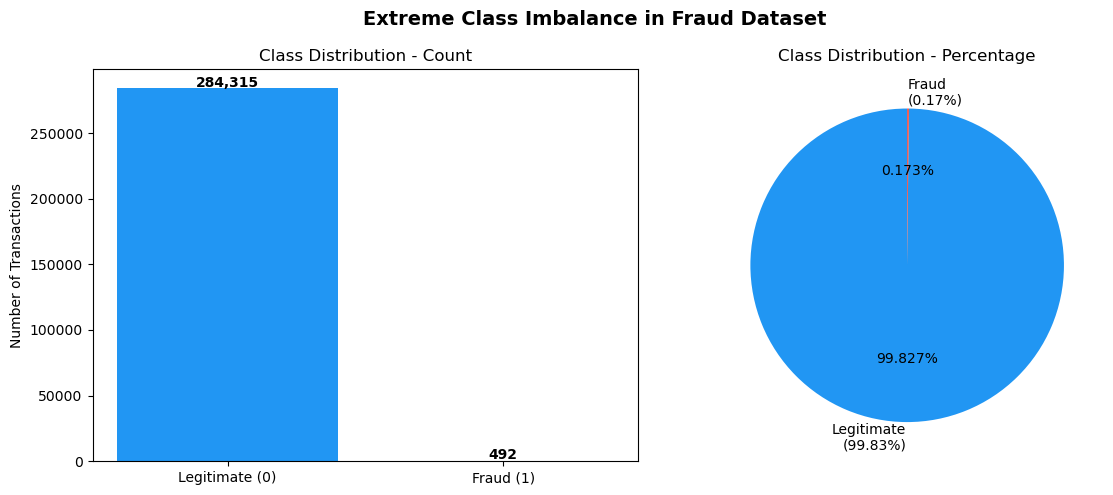

Plot 1 done


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], 
            class_counts.values,
            color=['#2196F3', '#F44336'])
axes[0].set_title('Class Distribution - Count')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v+1000 , f'{v:,}', ha='center', fontweight='bold')
axes[1].pie([284315, 492], 
            labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Class Distribution - Percentage')

plt.suptitle('Extreme Class Imbalance in Fraud Dataset', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 done")

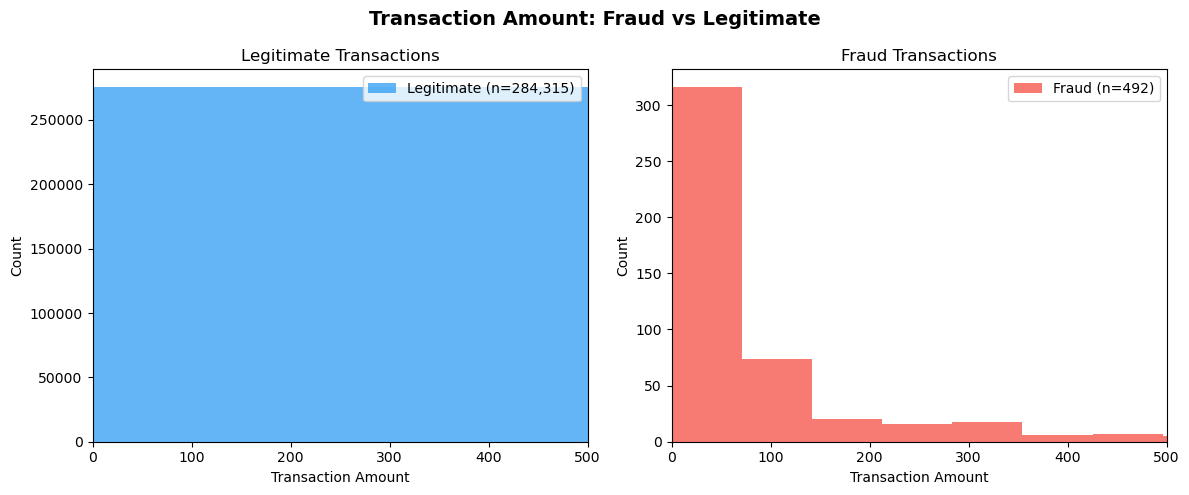

Legitimate - Mean: $88.29, Median: $22.00, Max: $25691.16
Fraud      - Mean: $122.21, Median: $9.25, Max: $2125.87


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

legit = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

axes[0].hist(legit, bins=50, color='#2196F3', alpha=0.7, label=f'Legitimate (n={len(legit):,})')
axes[0].set_title('Legitimate Transactions')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 500)
axes[0].legend()

axes[1].hist(fraud, bins=30, color='#F44336', alpha=0.7, label=f'Fraud (n={len(fraud):,})')
axes[1].set_title('Fraud Transactions')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 500)
axes[1].legend()

plt.suptitle('Transaction Amount: Fraud vs Legitimate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Legitimate - Mean: ${legit.mean():.2f}, Median: ${legit.median():.2f}, Max: ${legit.max():.2f}")
print(f"Fraud      - Mean: ${fraud.mean():.2f}, Median: ${fraud.median():.2f}, Max: ${fraud.max():.2f}")

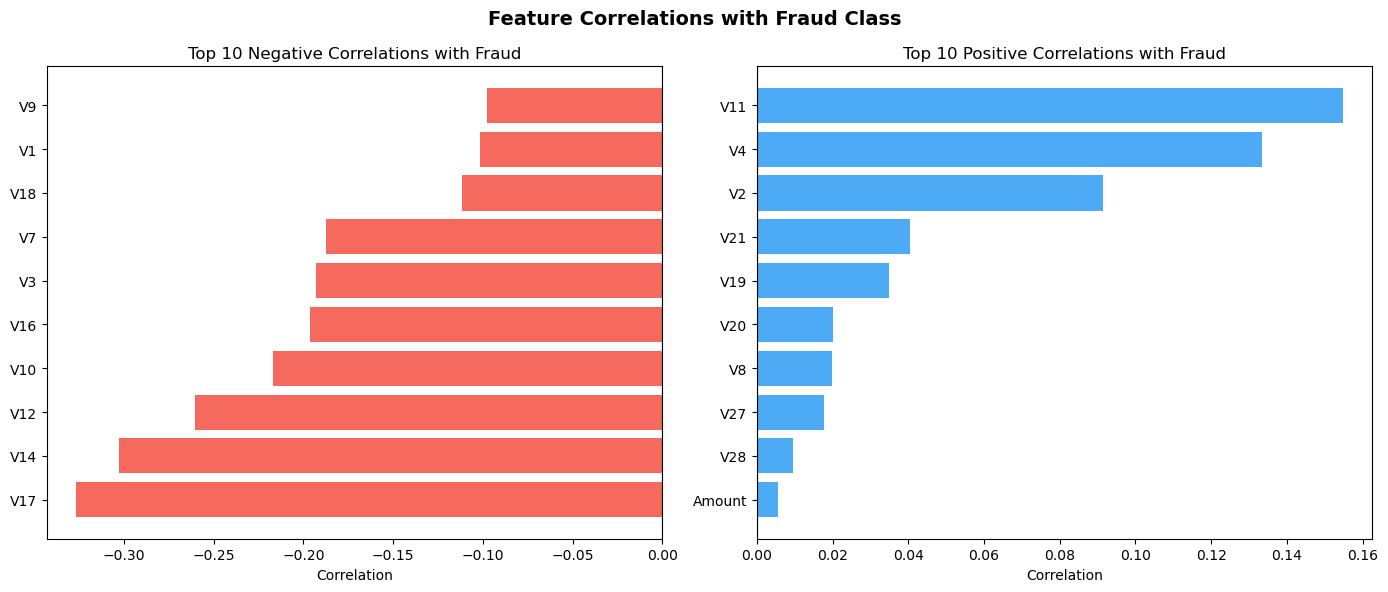

Top 5 features positively correlated with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top 5 features negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

correlations = df.corr()['Class'].drop('Class').sort_values()

neg_corr = correlations.head(10)
pos_corr = correlations.tail(10)

axes[0].barh(neg_corr.index, neg_corr.values, color='#F44336', alpha=0.8)
axes[0].set_title('Top 10 Negative Correlations with Fraud')
axes[0].set_xlabel('Correlation')
axes[0].axvline(x=0, color='black', linewidth=0.8)

axes[1].barh(pos_corr.index, pos_corr.values, color='#2196F3', alpha=0.8)
axes[1].set_title('Top 10 Positive Correlations with Fraud')
axes[1].set_xlabel('Correlation')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Feature Correlations with Fraud Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features positively correlated with fraud:")
print(correlations.tail(5))
print("\nTop 5 features negatively correlated with fraud:")
print(correlations.head(5))

In [6]:
X = df.drop('Class', axis=1)
Y = df['Class']

x_train, x_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=SEED,
    stratify=Y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print("Train size:", x_train.shape)
print("Val size:  ", x_val.shape)
print("Test size: ", x_test.shape)
print(f"\nTrain fraud %: {y_train.mean() * 100:.4f}%")
print(f"Val fraud %:   {y_val.mean() * 100:.4f}%")
print(f"Test fraud %:  {y_test.mean() * 100:.4f}%")

Train size: (199364, 30)
Val size:   (42721, 30)
Test size:  (42722, 30)

Train fraud %: 0.1725%
Val fraud %:   0.1732%
Test fraud %:  0.1732%


In [7]:
dm = DummyClassifier(strategy="most_frequent", random_state=SEED)
dm.fit(x_train, y_train)
dm_pred = dm.predict(x_test)
dm_prob = dm.predict_proba(x_test)[:, 1]

base_recall = recall_score(y_test, dm_pred, zero_division=0)
base_precision = precision_score(y_test, dm_pred, zero_division=0)
base_roc = roc_auc_score(y_test, dm_prob)
base_pr = average_precision_score(y_test, dm_prob)

print("=== DUMMY BASELINE ===")
print(f"Recall:    {base_recall:.4f}")
print(f"Precision: {base_precision:.4f}")
print(f"ROC-AUC:   {base_roc:.4f}")
print(f"PR-AUC:    {base_pr:.4f}")

=== DUMMY BASELINE ===
Recall:    0.0000
Precision: 0.0000
ROC-AUC:   0.5000
PR-AUC:    0.0017


In [8]:
lg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=1000,
        random_state=SEED
    ))
])

lg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"]
}

lg_grid = GridSearchCV(
    lg_pipe,
    param_grid=lg_param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1
)

lg_grid.fit(x_train, y_train)
print("Best params:", lg_grid.best_params_)
print("Best CV PR-AUC:", f"{lg_grid.best_score_:.4f}")

lg_prob_val = lg_grid.predict_proba(x_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, lg_prob_val)

res_lg = []
for pr, re, th in zip(precision[:-1], recall[:-1], thresholds):
    f1 = (2 * (pr * re) / (pr + re)) if (pr + re) != 0 else 0
    res_lg.append((f1, pr, re, th))

best = max(res_lg, key=lambda x: x[0])
lg_best_thresh = best[3]
print(f"Best threshold: {lg_best_thresh:.4f}")

lg_prob = lg_grid.predict_proba(x_test)[:, 1]
lg_pred = (lg_prob > lg_best_thresh).astype(int)

lg_roc = roc_auc_score(y_test, lg_prob)
lg_pr = average_precision_score(y_test, lg_prob)
lg_recall = recall_score(y_test, lg_pred)
lg_precision = precision_score(y_test, lg_pred)

print("\n=== LOGISTIC REGRESSION ===")
print(f"Recall:    {lg_recall:.4f}")
print(f"Precision: {lg_precision:.4f}")
print(f"ROC-AUC:   {lg_roc:.4f}")
print(f"PR-AUC:    {lg_pr:.4f}")

Best params: {'model__C': 0.01, 'model__penalty': 'l2'}
Best CV PR-AUC: 0.7856
Best threshold: 0.9999

=== LOGISTIC REGRESSION ===
Recall:    0.7568
Precision: 0.8235
ROC-AUC:   0.9826
PR-AUC:    0.7056


In [9]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        class_weight="balanced_subsample",
        bootstrap=True,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None]
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)
print("Best params:", rf_grid.best_params_)
print("Best CV PR-AUC:", f"{rf_grid.best_score_:.4f}")

rf_prob_val = rf_grid.predict_proba(x_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, rf_prob_val)

res_rf = []
for pr, re, th in zip(precision[:-1], recall[:-1], thresholds):
    f1 = (2 * (pr * re) / (pr + re)) if (pr + re) != 0 else 0
    res_rf.append((f1, pr, re, th))

best = max(res_rf, key=lambda x: x[0])
rf_best_thresh = best[3]
print(f"Best threshold: {rf_best_thresh:.4f}")

rf_prob = rf_grid.predict_proba(x_test)[:, 1]
rf_pred = (rf_prob > rf_best_thresh).astype(int)

rf_roc = roc_auc_score(y_test, rf_prob)
rf_pr = average_precision_score(y_test, rf_prob)
rf_recall = recall_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)

print("\n=== RANDOM FOREST ===")
print(f"Recall:    {rf_recall:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"ROC-AUC:   {rf_roc:.4f}")
print(f"PR-AUC:    {rf_pr:.4f}")

Best params: {'model__max_depth': 20, 'model__n_estimators': 200}
Best CV PR-AUC: 0.8671
Best threshold: 0.4050

=== RANDOM FOREST ===
Recall:    0.7568
Precision: 0.9333
ROC-AUC:   0.9499
PR-AUC:    0.8129


In [10]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight: {scale:.1f}")

xgb_pipe = Pipeline([
    ("model", XGBClassifier(
        scale_pos_weight=scale,
        eval_metric="aucpr",
        random_state=SEED,
        verbosity=0,
        n_jobs=-1
    ))
])

xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipe,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1
)

xgb_grid.fit(x_train, y_train)
print("Best params:", xgb_grid.best_params_)
print("Best CV PR-AUC:", f"{xgb_grid.best_score_:.4f}")

xgb_prob_val = xgb_grid.predict_proba(x_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, xgb_prob_val)

res_xgb = []
for pr, re, th in zip(precision[:-1], recall[:-1], thresholds):
    f1 = (2 * (pr * re) / (pr + re)) if (pr + re) != 0 else 0
    res_xgb.append((f1, pr, re, th))

best = max(res_xgb, key=lambda x: x[0])
xgb_best_thresh = best[3]
print(f"Best threshold: {xgb_best_thresh:.4f}")

xgb_prob = xgb_grid.predict_proba(x_test)[:, 1]
xgb_pred = (xgb_prob > xgb_best_thresh).astype(int)

xgb_roc = roc_auc_score(y_test, xgb_prob)
xgb_pr = average_precision_score(y_test, xgb_prob)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)

print("\n=== XGBOOST ===")
print(f"Recall:    {xgb_recall:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"ROC-AUC:   {xgb_roc:.4f}")
print(f"PR-AUC:    {xgb_pr:.4f}")

scale_pos_weight: 578.5
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV PR-AUC: 0.8756
Best threshold: 0.9971

=== XGBOOST ===
Recall:    0.7297
Precision: 0.9818
ROC-AUC:   0.9722
PR-AUC:    0.8268


In [11]:
smote = SMOTE(random_state=SEED)

# LG + SMOTE
lg_smt_pipe = ImbPipeline([
    ("smote", smote),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        random_state=SEED
    ))
])

lg_smt_grid = GridSearchCV(
    lg_smt_pipe,
    param_grid={
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l1", "l2"]
    },
    cv=5,
    scoring="average_precision",
    n_jobs=-1
)

lg_smt_grid.fit(x_train, y_train)
print("LG SMOTE best params:", lg_smt_grid.best_params_)

lg_smt_prob_val = lg_smt_grid.predict_proba(x_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, lg_smt_prob_val)
res = []
for pr, re, th in zip(precision[:-1], recall[:-1], thresholds):
    f1 = (2 * (pr * re) / (pr + re)) if (pr + re) != 0 else 0
    res.append((f1, pr, re, th))
lg_smt_thresh = max(res, key=lambda x: x[0])[3]

lg_smt_prob = lg_smt_grid.predict_proba(x_test)[:, 1]
lg_smt_pred = (lg_smt_prob > lg_smt_thresh).astype(int)
lg_smt_roc = roc_auc_score(y_test, lg_smt_prob)
lg_smt_pr = average_precision_score(y_test, lg_smt_prob)
lg_smt_recall = recall_score(y_test, lg_smt_pred)
lg_smt_precision = precision_score(y_test, lg_smt_pred)

print(f"\n=== LG SMOTE ===")
print(f"Recall:    {lg_smt_recall:.4f}")
print(f"Precision: {lg_smt_precision:.4f}")
print(f"ROC-AUC:   {lg_smt_roc:.4f}")
print(f"PR-AUC:    {lg_smt_pr:.4f}")

# RF + SMOTE
rf_smt_pipe = ImbPipeline([
    ("smote", smote),
    ("model", RandomForestClassifier(
        bootstrap=True,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_smt_grid = GridSearchCV(
    rf_smt_pipe,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20]
    },
    cv=5,
    scoring="average_precision",
    n_jobs=-1
)

rf_smt_grid.fit(x_train, y_train)
print("\nRF SMOTE best params:", rf_smt_grid.best_params_)

rf_smt_prob_val = rf_smt_grid.predict_proba(x_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, rf_smt_prob_val)
res = []
for pr, re, th in zip(precision[:-1], recall[:-1], thresholds):
    f1 = (2 * (pr * re) / (pr + re)) if (pr + re) != 0 else 0
    res.append((f1, pr, re, th))
rf_smt_thresh = max(res, key=lambda x: x[0])[3]

rf_smt_prob = rf_smt_grid.predict_proba(x_test)[:, 1]
rf_smt_pred = (rf_smt_prob > rf_smt_thresh).astype(int)
rf_smt_roc = roc_auc_score(y_test, rf_smt_prob)
rf_smt_pr = average_precision_score(y_test, rf_smt_prob)
rf_smt_recall = recall_score(y_test, rf_smt_pred)
rf_smt_precision = precision_score(y_test, rf_smt_pred)

print(f"\n=== RF SMOTE ===")
print(f"Recall:    {rf_smt_recall:.4f}")
print(f"Precision: {rf_smt_precision:.4f}")
print(f"ROC-AUC:   {rf_smt_roc:.4f}")
print(f"PR-AUC:    {rf_smt_pr:.4f}")

LG SMOTE best params: {'model__C': 0.01, 'model__penalty': 'l1'}

=== LG SMOTE ===
Recall:    0.7568
Precision: 0.8485
ROC-AUC:   0.9846
PR-AUC:    0.6951

RF SMOTE best params: {'model__max_depth': 20, 'model__n_estimators': 200}

=== RF SMOTE ===
Recall:    0.7568
Precision: 0.9032
ROC-AUC:   0.9513
PR-AUC:    0.8201


In [12]:
results = pd.DataFrame([
    ["Dummy",       base_roc,   base_pr,   base_recall,   base_precision],
    ["LG Balanced", lg_roc,     lg_pr,     lg_recall,     lg_precision],
    ["RF Balanced", rf_roc,     rf_pr,     rf_recall,     rf_precision],
    ["XGBoost",     xgb_roc,    xgb_pr,    xgb_recall,    xgb_precision],
    ["LG SMOTE",    lg_smt_roc, lg_smt_pr, lg_smt_recall, lg_smt_precision],
    ["RF SMOTE",    rf_smt_roc, rf_smt_pr, rf_smt_recall, rf_smt_precision],
], columns=["Model", "ROC_AUC", "PR_AUC", "Recall", "Precision"])

results = results.sort_values("PR_AUC", ascending=False).reset_index(drop=True)
print("=== MODEL COMPARISON (sorted by PR-AUC) ===")
print(results.to_string(index=False))

# Cost function
def compute_cost(y_true, y_pred, fp_cost=50, fn_cost=10000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = fp * fp_cost + fn * fn_cost
    print(f"  TP:{tp} FP:{fp} FN:{fn} TN:{tn}")
    print(f"  Cost = {fp}×{fp_cost} + {fn}×{fn_cost} = ${total:,}")
    return total

print("\n=== COST ANALYSIS (FP=$50, FN=$10,000) ===")
print("LG Balanced:")
lg_cost = compute_cost(y_test, lg_pred)
print("RF Balanced:")
rf_cost = compute_cost(y_test, rf_pred)
print("XGBoost:")
xgb_cost = compute_cost(y_test, xgb_pred)
print("LG SMOTE:")
lg_smt_cost = compute_cost(y_test, lg_smt_pred)
print("RF SMOTE:")
rf_smt_cost = compute_cost(y_test, rf_smt_pred)

costs = {
    "LG Balanced": lg_cost,
    "RF Balanced": rf_cost,
    "XGBoost": xgb_cost,
    "LG SMOTE": lg_smt_cost,
    "RF SMOTE": rf_smt_cost
}
best_model = min(costs, key=costs.get)
print(f"\nLowest cost model: {best_model} = ${costs[best_model]:,}")

=== MODEL COMPARISON (sorted by PR-AUC) ===
      Model  ROC_AUC   PR_AUC   Recall  Precision
    XGBoost 0.972242 0.826832 0.729730   0.981818
   RF SMOTE 0.951339 0.820085 0.756757   0.903226
RF Balanced 0.949937 0.812911 0.756757   0.933333
LG Balanced 0.982593 0.705590 0.756757   0.823529
   LG SMOTE 0.984617 0.695124 0.756757   0.848485
      Dummy 0.500000 0.001732 0.000000   0.000000

=== COST ANALYSIS (FP=$50, FN=$10,000) ===
LG Balanced:
  TP:56 FP:12 FN:18 TN:42636
  Cost = 12×50 + 18×10000 = $180,600
RF Balanced:
  TP:56 FP:4 FN:18 TN:42644
  Cost = 4×50 + 18×10000 = $180,200
XGBoost:
  TP:54 FP:1 FN:20 TN:42647
  Cost = 1×50 + 20×10000 = $200,050
LG SMOTE:
  TP:56 FP:10 FN:18 TN:42638
  Cost = 10×50 + 18×10000 = $180,500
RF SMOTE:
  TP:56 FP:6 FN:18 TN:42642
  Cost = 6×50 + 18×10000 = $180,300

Lowest cost model: RF Balanced = $180,200


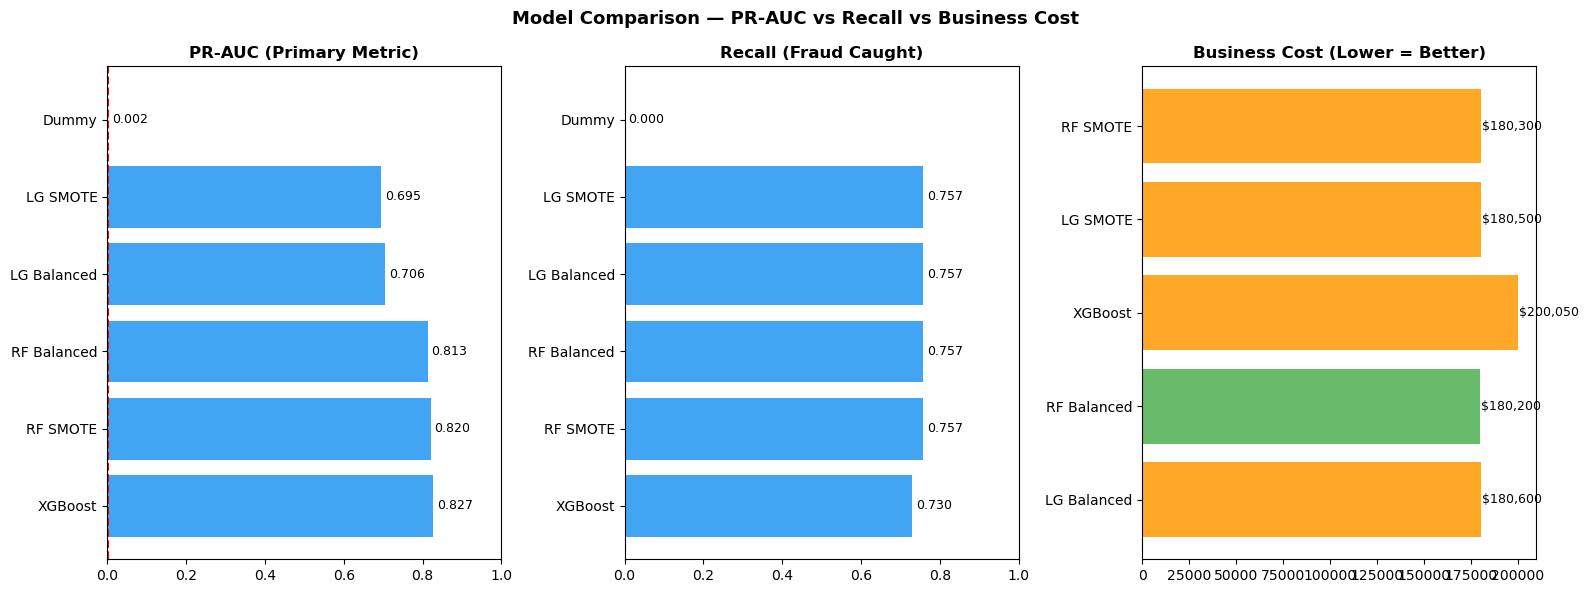

Comparison plot done


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

models_name = results['Model'].tolist()
colors = ['#F44336' if m == 'Dummy' else '#2196F3' for m in models_name]

# PR-AUC bar chart
bars = axes[0].barh(models_name, results['PR_AUC'], color=colors, alpha=0.85)
axes[0].set_title('PR-AUC (Primary Metric)', fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=base_pr, color='red', linestyle='--', linewidth=1.5, label='Dummy baseline')
for bar, val in zip(bars, results['PR_AUC']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

# Recall bar chart
bars2 = axes[1].barh(models_name, results['Recall'], color=colors, alpha=0.85)
axes[1].set_title('Recall (Fraud Caught)', fontweight='bold')
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, results['Recall']):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

# Cost bar chart
cost_models = list(costs.keys())
cost_values = list(costs.values())
cost_colors = ['#4CAF50' if v == min(cost_values) else '#FF9800' for v in cost_values]
bars3 = axes[2].barh(cost_models, cost_values, color=cost_colors, alpha=0.85)
axes[2].set_title('Business Cost (Lower = Better)', fontweight='bold')
for bar, val in zip(bars3, cost_values):
    axes[2].text(val + 500, bar.get_y() + bar.get_height()/2,
                f'${val:,}', va='center', fontsize=9)

plt.suptitle('Model Comparison — PR-AUC vs Recall vs Business Cost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot done")

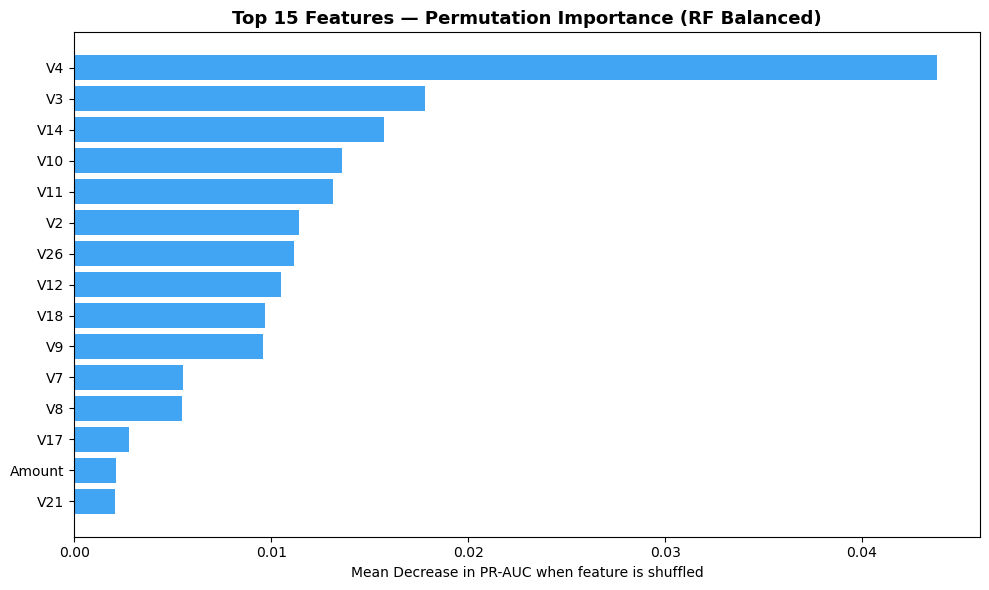


Top 10 Most Important Features:
Feature  Importance
     V4    0.043796
     V3    0.017813
    V14    0.015731
    V10    0.013616
    V11    0.013120
     V2    0.011388
    V26    0.011149
    V12    0.010494
    V18    0.009668
     V9    0.009600


In [14]:
perm = permutation_importance(
    rf_grid.best_estimator_,
    x_test, y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="average_precision",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": x_test.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'][::-1],
         perm_df['Importance'][::-1],
         color='#2196F3', alpha=0.85)
plt.title('Top 15 Features — Permutation Importance (RF Balanced)',
          fontweight='bold', fontsize=13)
plt.xlabel('Mean Decrease in PR-AUC when feature is shuffled')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
print(perm_df.head(10).to_string(index=False))

In [15]:
print("=" * 55)
print("   CREDIT CARD FRAUD DETECTION - FINAL SUMMARY")
print("=" * 55)

print(f"""
DATASET
  Transactions : 284,807
  Fraud rate   : 0.17% (extreme imbalance)
  Features     : 30 (V1-V28 + Time + Amount)

APPROACH
  - Compared 5 models across 2 imbalance strategies
  - Tuned hyperparameters using PR-AUC (not accuracy)
  - Manual threshold tuning on validation set
  - Final selection based on business cost

MODEL RESULTS (sorted by PR-AUC)
{results[['Model','PR_AUC','Recall','Precision']].to_string(index=False)}

COST ANALYSIS (FP=$50, FN=$10,000)
  RF Balanced  : ${rf_cost:,}  ← SELECTED
  RF SMOTE     : ${rf_smt_cost:,}
  LG SMOTE     : ${lg_smt_cost:,}
  LG Balanced  : ${lg_cost:,}
  XGBoost      : ${xgb_cost:,}

KEY INSIGHTS
  1. XGBoost had best PR-AUC (0.827) but highest cost
     because it missed 2 more fraud cases than RF
  2. SMOTE did not improve over class_weight for this dataset
  3. V4 was most important feature by far (permutation)
  4. Cost-based selection changed the final model choice

FINAL MODEL : RF Balanced (cost = ${rf_cost:,})
""")
print("=" * 55)

   CREDIT CARD FRAUD DETECTION - FINAL SUMMARY

DATASET
  Transactions : 284,807
  Fraud rate   : 0.17% (extreme imbalance)
  Features     : 30 (V1-V28 + Time + Amount)

APPROACH
  - Compared 5 models across 2 imbalance strategies
  - Tuned hyperparameters using PR-AUC (not accuracy)
  - Manual threshold tuning on validation set
  - Final selection based on business cost

MODEL RESULTS (sorted by PR-AUC)
      Model   PR_AUC   Recall  Precision
    XGBoost 0.826832 0.729730   0.981818
   RF SMOTE 0.820085 0.756757   0.903226
RF Balanced 0.812911 0.756757   0.933333
LG Balanced 0.705590 0.756757   0.823529
   LG SMOTE 0.695124 0.756757   0.848485
      Dummy 0.001732 0.000000   0.000000

COST ANALYSIS (FP=$50, FN=$10,000)
  RF Balanced  : $180,200  ← SELECTED
  RF SMOTE     : $180,300
  LG SMOTE     : $180,500
  LG Balanced  : $180,600
  XGBoost      : $200,050

KEY INSIGHTS
  1. XGBoost had best PR-AUC (0.827) but highest cost
     because it missed 2 more fraud cases than RF
  2. SMOT